In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

color_list = ['#0072b2', '#009e73', '#e69f00', '#d55e00',
              '#cc79a7', '#f0e442', '#56b4e9', '#000000']

#   On regarde le nombre d'avalanche par unité d'énergie en fonction de la taille du systeme

In [9]:
Tproject = ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu5n", "/data1/DATA_Duplat/Brut/Cut_off_size/Cu4n", "/data1/DATA_Duplat/Brut/PDF/PD5n"]
nbfolder = 14
Tnu = [read_parameters("{}{}".format(Tproject[-1], i+1))[2] for i in range(nbfolder)]
size = np.array([64,128, 256])


result = np.zeros((len(size), nbfolder))
for j, project in enumerate(Tproject):
    for i in range(nbfolder):
        data = np.loadtxt("{}{}/time_outputB.txt".format(project, i+1), comments = "#", max_rows = int(1e4))
        dt = data[1,0]-data[0,0]
        dE = np.mean(np.diff(data[:,1]))
        nb_ava_per_E_unit = dt/dE
        result[j, i] = nb_ava_per_E_unit
        


/tmp/ipykernel_574246/3104449736.py:10: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=10000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("{}{}/time_outputB.txt".format(project, i+1), comments = "#", max_rows = int(1e4))


/tmp/ipykernel_453806/2944567841.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]


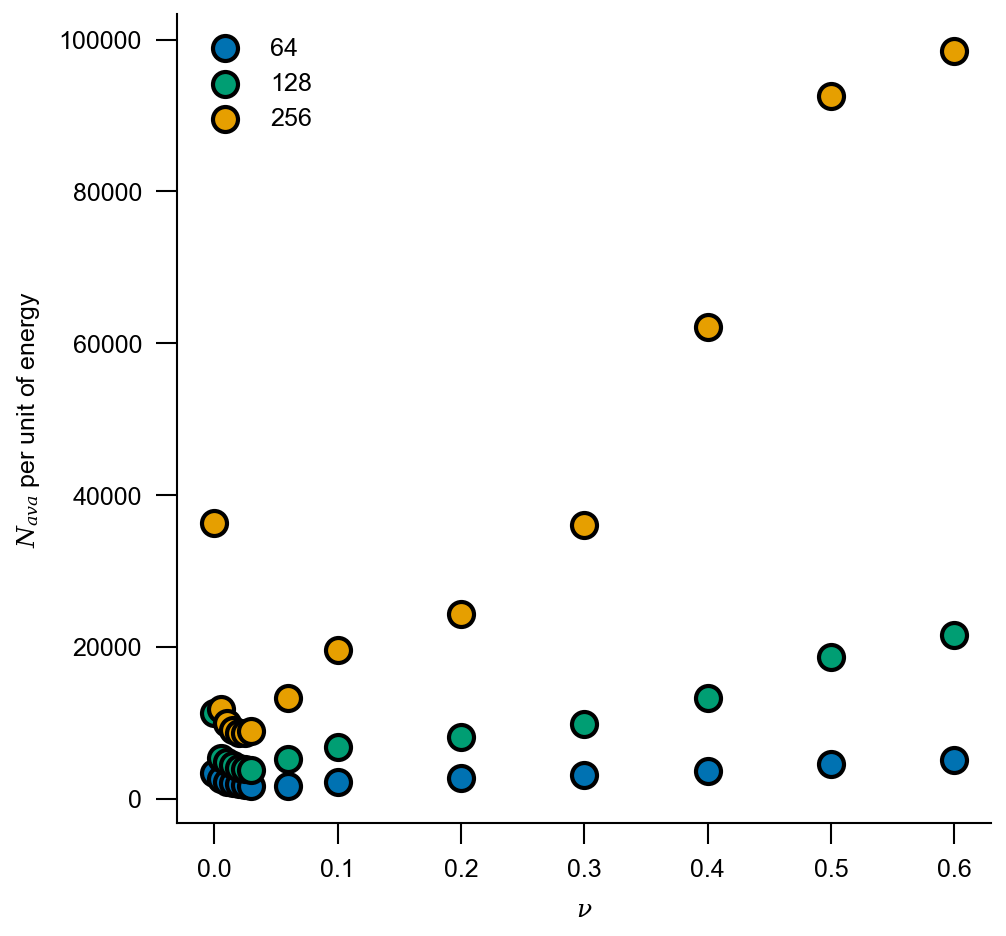

/tmp/ipykernel_453806/2944567841.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(size**2, result[:,i], label = nu, c = colors[i])


[ 2.71164686 25.87270483 26.21819167 24.33847537 20.6912182  16.051564
 11.46363762  3.20411792  3.09168221  3.55864332  1.83837632  0.70738669
  0.51570949  0.72470269]
[0.85748464 0.55179442 0.53572602 0.53429928 0.54390405 0.56620727
 0.5995633  0.75466342 0.7900097  0.7964439  0.8894113  1.02265216
 1.08793969 1.06454526]


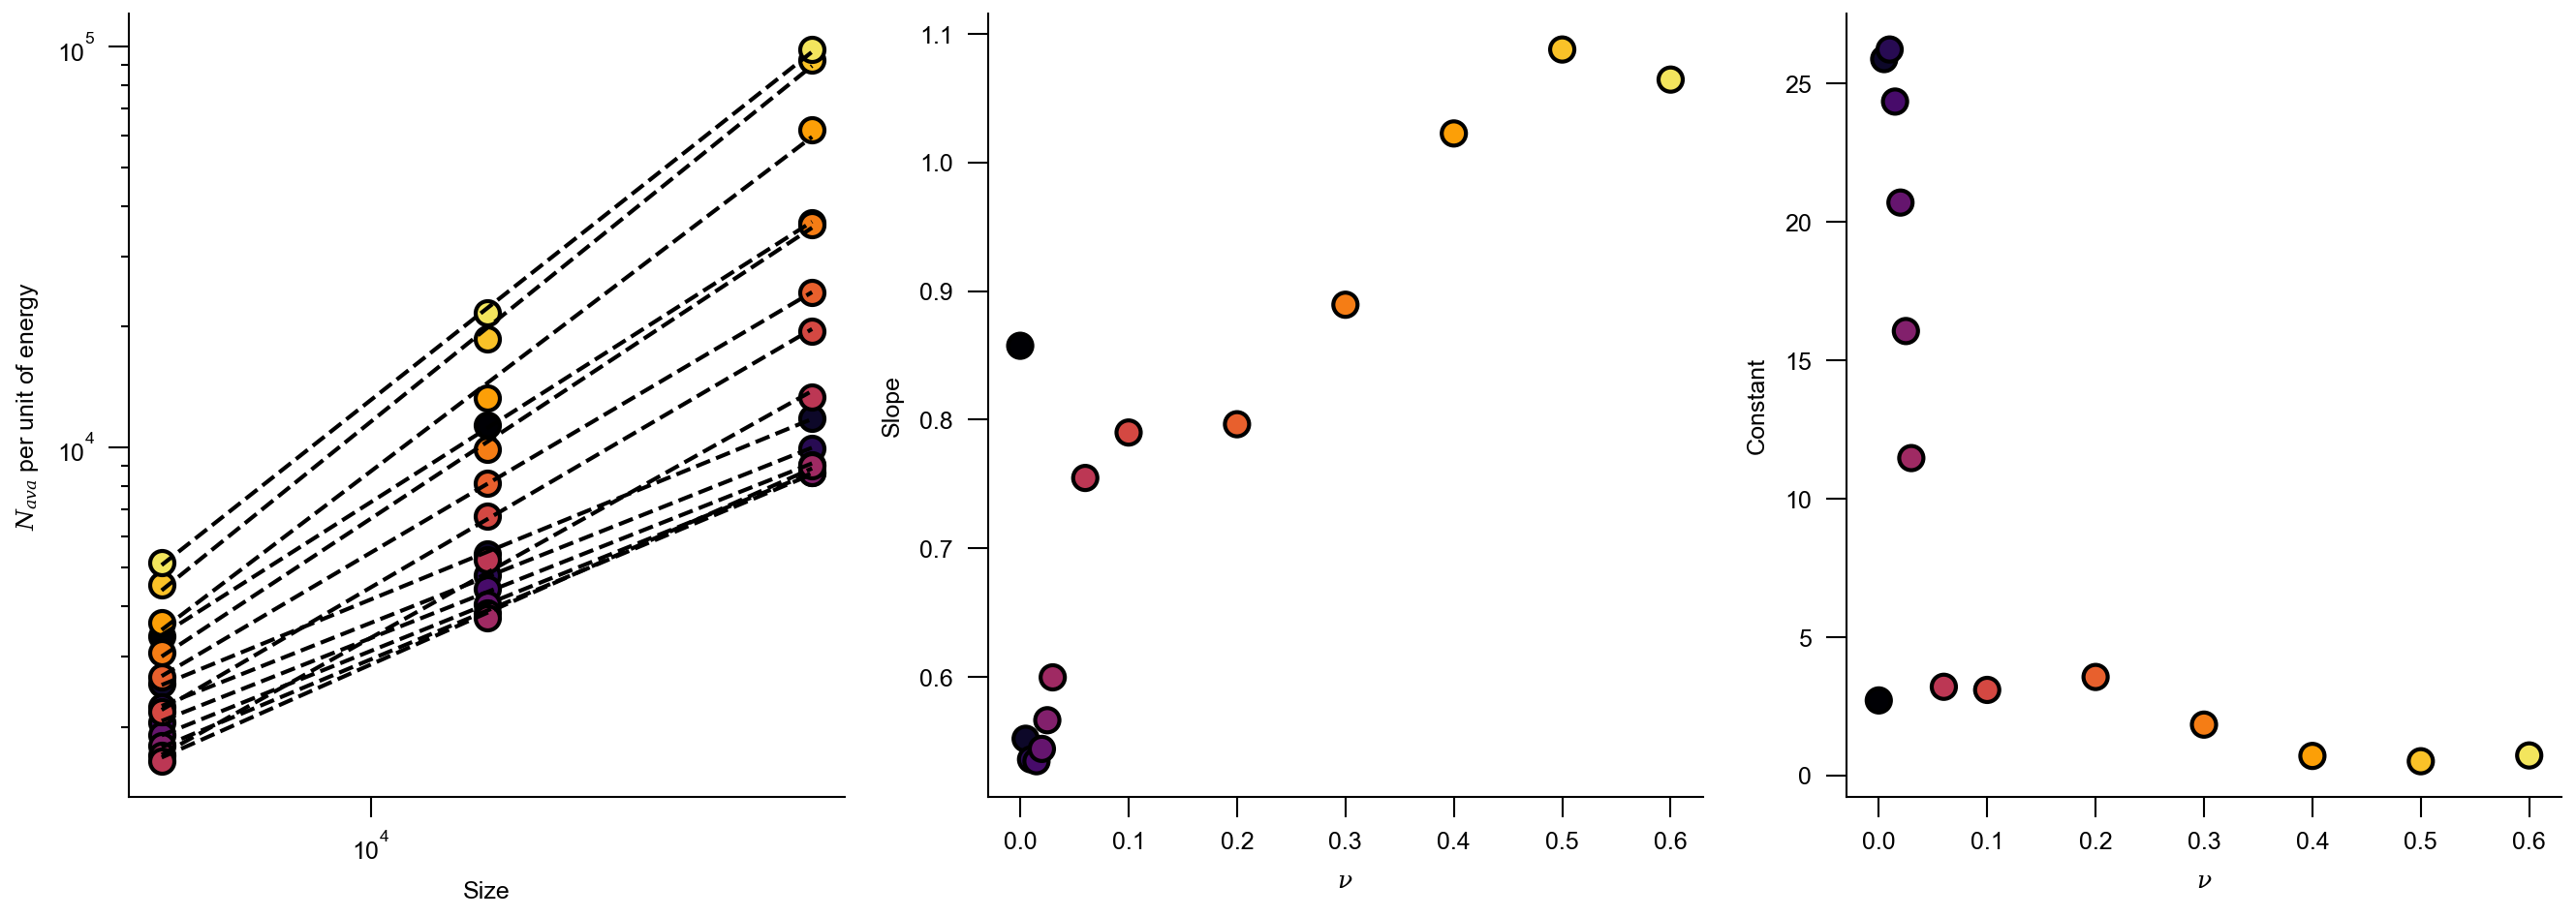

In [ ]:
C = np.zeros_like(Tnu)
exponent = np.zeros_like(Tnu)



NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    
    fig, ax = plt.subplots(figsize = (3.5 ,3.5))
    for i, s in enumerate(size):
        ax.scatter(Tnu, result[i], label = s, c = color_list[i])
        
    ax.set_xlabel(r"$\nu$")
    ax.set_ylabel(r"$N_{ava}$ per unit of energy")
    ax.legend()
    plt.show()    

    
    fig, (ax, ax2, ax3) = plt.subplots(1,3,figsize = (10.8 ,3.5))
    for i, nu in enumerate(Tnu[:]):
        ax.scatter(size**2, result[:,i], label = nu, c = colors[i])
        # if nu in [0.01, 0.6]:
        xfit = size**2
        
        # popt, pcov = curve_fit(expfct2, xfit, np.log(result[:,i]), p0 = [0.5, 3], maxfev = 1000)
        # yfit = np.exp(expfct2(xfit, *popt))
        popt, pcov = curve_fit(powerlaw2, np.log(xfit), np.log(result[:,i]), p0 = [0.5, 3], maxfev = 1000)
        C[i], exponent[i] = popt
        yfit = np.exp(powerlaw2(np.log(xfit), *popt))
        ax.plot(xfit, yfit, c = 'k', ls = '--', label = np.round(popt[1], 2))
        
    ax2.scatter(Tnu,exponent, c = colors)
    ax3.scatter(Tnu, np.exp(C), c = colors)
    print(np.exp(C))
    print(exponent)
        
    ax.set_xlabel("Size")
    ax.set_ylabel(r"$N_{ava}$ per unit of energy")
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax2.set_xlabel(r'$\nu$')
    ax2.set_ylabel('Slope')
    
    ax3.set_xlabel(r"$\nu$")
    ax3.set_ylabel("Constant")
    plt.show()
        
        

In [4]:
A = size**2
tau_c = 1.22
s = np.arange(1,100001)
Ps = np.zeros((len(Tnu), len(s)))

temp_size = np.array([32,64,128,256, 512])
log_temp_area = np.log(temp_size**2)
log_bin_edge = (log_temp_area[1:] + log_temp_area[:-1])/2
bin_edge = np.exp(log_bin_edge)
bin_diff = np.diff(bin_edge)

for j, nu in enumerate(Tnu):
    for i in range(len(s)):
        # Ps[j, i] = (i+1)**-tau_c * np.sum(A**(-3/2)*result[:,j]*np.exp(-(i+1)/A)*bin_diff)
        Ps[j, i] = (i+1)**-tau_c * np.sum(A**(-3/2)*(np.exp(C[j])*A**exponent[j])*np.exp(-(i+1)/A)*bin_diff)
        


/tmp/ipykernel_453806/2067277592.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]


-1.2376933237738936
-1.2448851103403356
-1.245303128995345
-1.2453403868478723
-1.2450900079973595
-1.2445127470874495
-1.2436611095011876
-1.2399257079028503
-1.2391344622526195
-1.2389930627767731
-1.2370443289094926
-1.2345718380103148
-1.2335001054082335
-1.2338736609155019


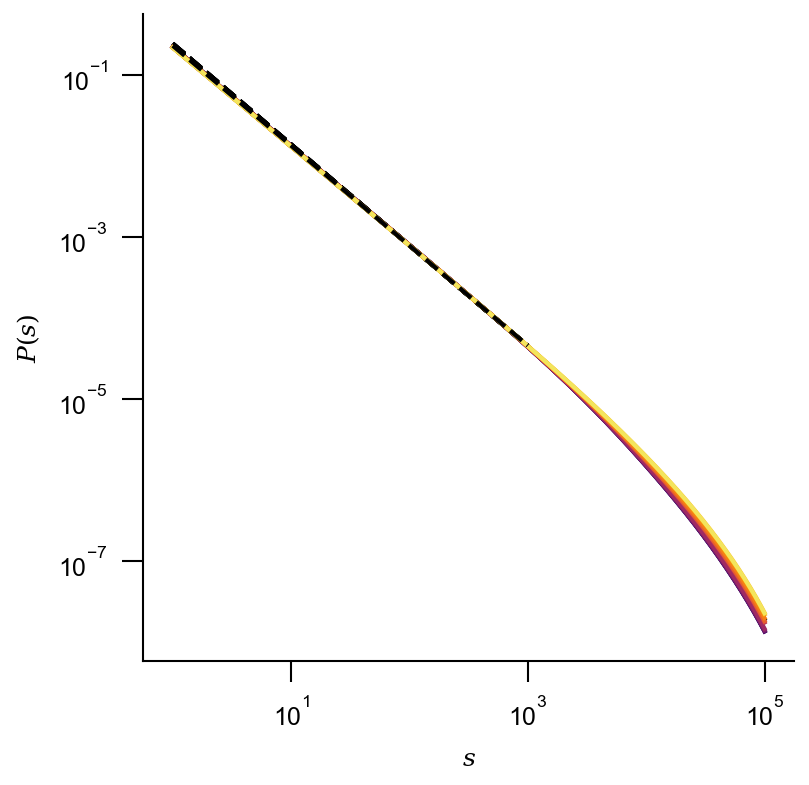

In [5]:
NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]


s_max = int(1e3)
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (2.8,2.8))
    for j in range(len(Tnu)):
        Ps[j] /=np.sum(Ps[j])*1 #1 is the bin width as there is one bin for eevery size*bin_diff
        ax.plot(s, Ps[j], c = colors[j], lw = 1)
        popt, pcov = curve_fit(powerlaw2, np.log(s[:s_max]), np.log(Ps[j, :s_max]), p0 = [0.5, 1.6], maxfev = 1000)
        tau = popt[1]
        print(tau)
        yfit = np.exp(powerlaw2(np.log(s[:s_max]), *popt))
        ax.plot(s[:s_max], yfit, c = 'k', ls = '--')
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$P(s)$")
plt.show()

In [2]:
# Tfolderpath = ["/data1/DATA_Duplat/Brut/PDF/PD11n1"]
# results2 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
# Thisto_s2, Tbins_s2, Tnonzero_s2, _, _ = zip(*results2)

folder = "/data1/DATA_Duplat/Brut/PDF/PD11n2"
histo_s4, bins_s4, nonzero_s4, _, _ = new_PDF("{}/stat_histosize.txt".format(folder), nbins = 4) 

data = np.loadtxt("{}/time_outputB.txt".format(folder), comments = "#", max_rows = int(1e4))
dt = data[1,0]- data[0,0]
dE = np.mean(np.diff(data[:,1]))
nb_ava_per_E_unit_s4 = dt/dE

folder = "/data1/DATA_Duplat/Brut/PDF/PD11n3"
histo_s8, bins_s8, nonzero_s8, _, _ = new_PDF("{}/stat_histosize.txt".format(folder), nbins = 8) 

data = np.loadtxt("{}/time_outputB.txt".format(folder), comments = "#", max_rows = int(1e4))
dt = data[1,0]- data[0,0]
dE = np.mean(np.diff(data[:,1]))
nb_ava_per_E_unit_s8 = dt/dE

folder = "/data1/DATA_Duplat/Brut/PDF/PD11n4"
histo_s16, bins_s16, nonzero_s16, _, _ = new_PDF("{}/stat_histosize.txt".format(folder), nbins = 10) 

data = np.loadtxt("{}/time_outputB.txt".format(folder), comments = "#", max_rows = int(1e4))
dt = data[1,0]- data[0,0]
dE = np.mean(np.diff(data[:,1]))
nb_ava_per_E_unit_s16 = dt/dE

folder = "/data1/DATA_Duplat/Brut/PDF/PD11n5"
histo_s32, bins_s32, nonzero_s32, _, _ = new_PDF("{}/stat_histosize.txt".format(folder), nbins = 10) 

data = np.loadtxt("{}/time_outputB.txt".format(folder), comments = "#", max_rows = int(1e4))
dt = data[1,0]- data[0,0]
dE = np.mean(np.diff(data[:,1]))
nb_ava_per_E_unit_s32 = dt/dE



/tmp/ipykernel_574246/120101357.py:8: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=10000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("{}/time_outputB.txt".format(folder), comments = "#", max_rows = int(1e4))
/tmp/ipykernel_574246/120101357.py:16: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=10000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If

In [3]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu5n{}".format(nb) for nb in [1]]
Tnu64 = [read_parameters(folder)[2] for folder in Tfolderpath]

results64 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s64, Tbins_s64, Tnonzero_s64, _, _ = zip(*results64)

In [4]:
Tfolderpath = [f'/data1/DATA_Duplat/Brut/Cut_off_size/Cu4n{nb}' for nb in [1]]
Tnu128 = [read_parameters(folder)[2] for folder in Tfolderpath]

results128 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s128, Tbins_s128, Tnonzero_s128, _, _ = zip(*results128)

In [5]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/PDF/PD5n{}".format(nb) for nb in [1]]
Tnu256 = [read_parameters(folder)[2] for folder in Tfolderpath]

results256 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s256, Tbins_s256,  Tnonzero_s256, _, _ = zip(*results256)

In [6]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu6n1"]
Tnu512 = [read_parameters(folder)[2] for folder in Tfolderpath]
Tnbins = [50,0,0]

results512 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder), nbins) for (folder, nbins) in zip(Tfolderpath, Tnbins))
Thisto_s512, Tbins_s512, Tnonzero_s512, _, _ = zip(*results512)

data = np.loadtxt("/data1/DATA_Duplat/Brut/Cut_off_size/Cu6n1/time_outputB.txt")
dt = data[1,0]-data[0,0]
dE = np.mean(np.diff(data[:,1]))
nb_ava_per_E_unit_512 = dt/dE

/tmp/ipykernel_574246/827021332.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


1.7777641416778605 0.7596681368278599


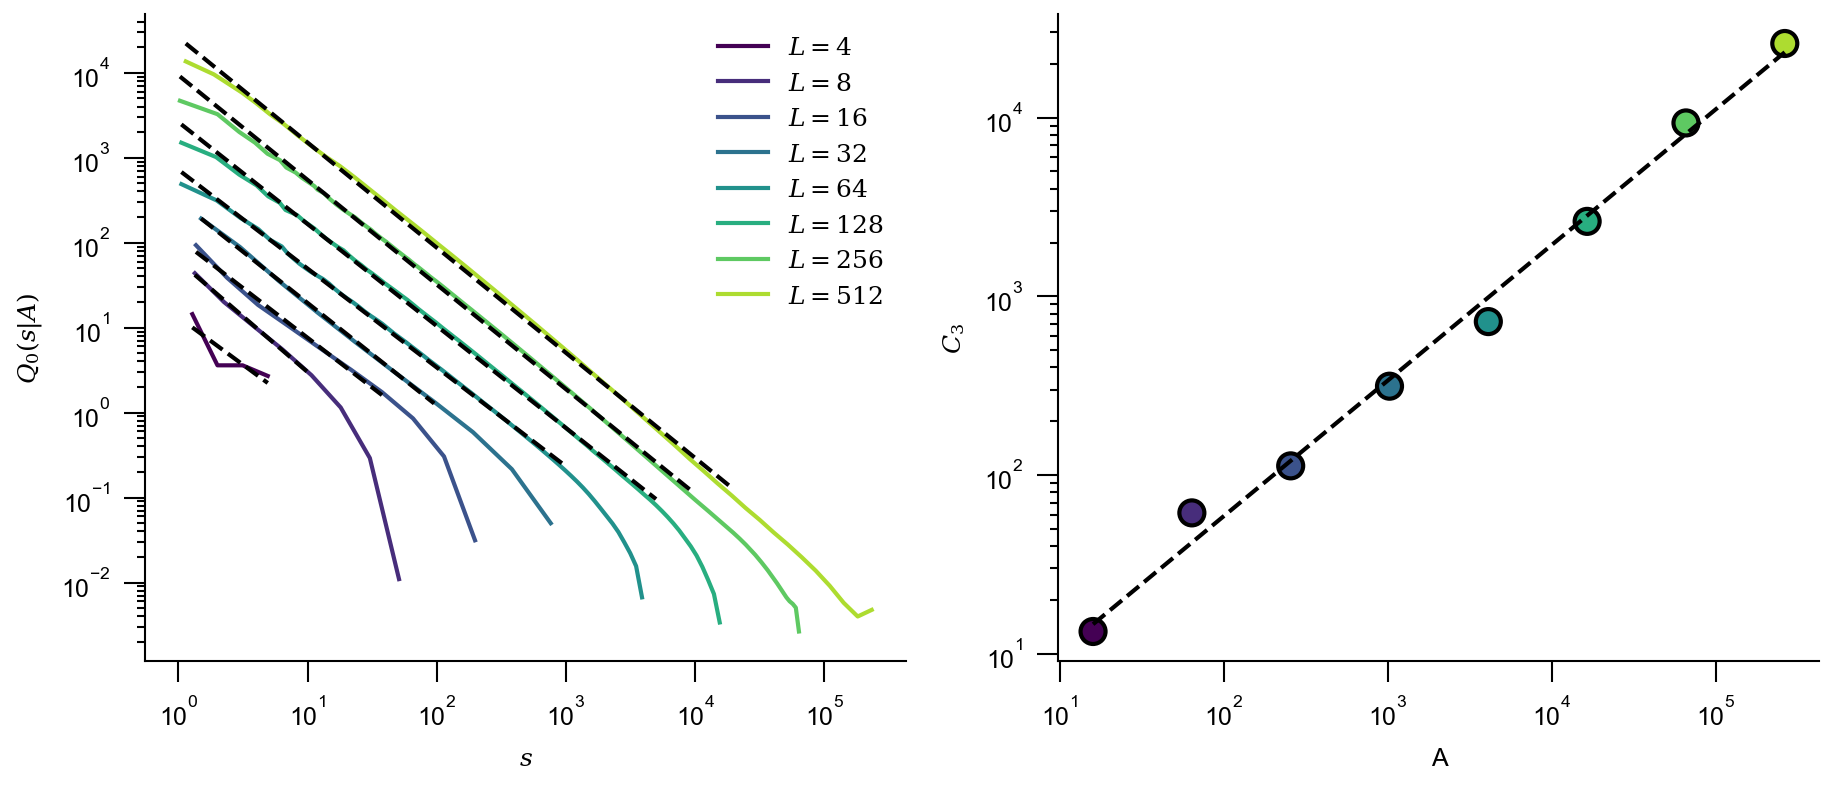

In [10]:
tau_Q = np.zeros(4)
const_Q = np.zeros(4)

NCURVES = 8
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax, ax2) = plt.subplots(1,2,figsize = (7.2,2.8))
    
    
   
   
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s64, Tbins_s64, np.array(Tnu64))):
        if i == 0:
            leg1 = ax.plot(bins,histo*result[0,0], c = colors[4], label = '$L = 64$')[0]
            s_max = np.argwhere(bins > int(1e3))[0,0]
            popt, pcov = curve_fit(powerlaw2, np.log(bins[:s_max]), np.log(histo[:s_max]*result[0,0]), p0 = [0.5, 1.6], maxfev = 1000)
            tau_Q[0]= popt[1]
            const_Q[0] = np.exp(popt[0])

            yfit = np.exp(powerlaw2(np.log(bins[:s_max]), *popt))
            ax.plot(bins[:s_max], yfit, c = 'k', ls = '--')
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s128, Tbins_s128, np.array(Tnu128))):
        if i == 0:
            leg2 = ax.plot(bins,histo*result[1,0], c = colors[5], label = '$L = 128$')[0]
            s_max = np.argwhere(bins > int(5e3))[0,0]
            popt, pcov = curve_fit(powerlaw2, np.log(bins[:s_max]), np.log(histo[:s_max]*result[1,0]), p0 = [0.5, 1.6], maxfev = 1000)
            tau_Q[1]= popt[1]
            const_Q[1] = np.exp(popt[0])
            yfit = np.exp(powerlaw2(np.log(bins[:s_max]), *popt))
            ax.plot(bins[:s_max], yfit, c = 'k', ls = '--')

    for i, (histo, bins, nu) in enumerate(zip(Thisto_s256, Tbins_s256, np.array(Tnu256))):
        if i == 0:
            leg3 = ax.plot(bins,histo*result[2,0], c = colors[6], label = '$L = 256$')[0]
            s_max = np.argwhere(bins > int(1e4))[0,0]
            popt, pcov = curve_fit(powerlaw2, np.log(bins[:s_max]), np.log(histo[:s_max]*result[2,0]), p0 = [0.5, 1.6], maxfev = 1000)
            tau_Q[2]= popt[1]
            const_Q[2] = np.exp(popt[0])
            yfit = np.exp(powerlaw2(np.log(bins[:s_max]), *popt))
            ax.plot(bins[:s_max], yfit, c = 'k', ls = '--')
            
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s512, Tbins_s512, np.array(Tnu512))):
        if i == 0:

            leg4 = ax.plot(bins,histo*nb_ava_per_E_unit_512, c = colors[7], label = '$L = 512$')[0]
            s_max = np.argwhere(bins > int(2e4))[0,0]
            popt, pcov = curve_fit(powerlaw2, np.log(bins[:s_max]), np.log(histo[:s_max]*nb_ava_per_E_unit_512), p0 = [0.5, 1.6], maxfev = 1000)
            tau_Q[3]= popt[1]
            const_Q[3] = np.exp(popt[0])
            yfit = np.exp(powerlaw2(np.log(bins[:s_max]), *popt))
            ax.plot(bins[:s_max], yfit, c = 'k', ls = '--')
            
            
            
    leg5 = ax.plot(bins_s4,histo_s4*nb_ava_per_E_unit_s4, c = colors[0], label = '$L = 4$')[0]
    popt, pcov = curve_fit(powerlaw2, np.log(bins_s4[:]), np.log(histo_s4[:]*nb_ava_per_E_unit_s4), p0 = [0.5, 1.6], maxfev = 1000)
    tau_Q = np.insert(tau_Q, 0, popt[1])
    const_Q = np.insert(const_Q, 0, np.exp(popt[0]))
    yfit = np.exp(powerlaw2(np.log(bins_s4[:]), *popt))
    ax.plot(bins_s4[:], yfit, c = 'k', ls = '--')
    
    
    leg6 = ax.plot(bins_s8,histo_s8*nb_ava_per_E_unit_s8, c = colors[1], label = '$L = 8$')[0]
    s_max = np.argwhere(bins_s8 > 10)[1,0]
    popt, pcov = curve_fit(powerlaw2, np.log(bins_s8[:s_max]), np.log(histo_s8[:s_max]*nb_ava_per_E_unit_s8), p0 = [0.5, 1.6], maxfev = 1000)
    tau_Q = np.insert(tau_Q, 1, popt[1])
    const_Q = np.insert(const_Q, 1, np.exp(popt[0]))
    yfit = np.exp(powerlaw2(np.log(bins_s8[:s_max]), *popt))
    ax.plot(bins_s8[:s_max], yfit, c = 'k', ls = '--')
    
    
    leg7 = ax.plot(bins_s16,histo_s16*nb_ava_per_E_unit_s16, c = colors[2], label = '$L = 16$')[0]
    s_max = np.argwhere(bins_s16 > 50)[0,0]
    popt, pcov = curve_fit(powerlaw2, np.log(bins_s16[:s_max]), np.log(histo_s16[:s_max]*nb_ava_per_E_unit_s16), p0 = [0.5, 1.6], maxfev = 1000)
    tau_Q = np.insert(tau_Q, 2, popt[1])
    const_Q = np.insert(const_Q, 2, np.exp(popt[0]))
    yfit = np.exp(powerlaw2(np.log(bins_s16[:s_max]), *popt))
    ax.plot(bins_s16[:s_max], yfit, c = 'k', ls = '--')
    
    leg8 = ax.plot(bins_s32,histo_s32*nb_ava_per_E_unit_s32, c = colors[3], label = '$L = 32$')[0]
    s_max = np.argwhere(bins_s32 > 100)[0,0]
    popt, pcov = curve_fit(powerlaw2, np.log(bins_s32[:s_max]), np.log(histo_s32[:s_max]*nb_ava_per_E_unit_s32), p0 = [0.5, 1.6], maxfev = 1000)
    tau_Q = np.insert(tau_Q, 3, popt[1])
    const_Q = np.insert(const_Q, 3, np.exp(popt[0]))
    yfit = np.exp(powerlaw2(np.log(bins_s32[:s_max]), *popt))
    ax.plot(bins_s32[:s_max], yfit, c = 'k', ls = '--')
    
    

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$Q_0(s|A)$')

    ax.legend(handles=[leg5, leg6, leg7, leg8, leg1, leg2, leg3, leg4])
    
    size = np.array([4,8,16,32,64,128,256,512])**2
    
    ax2.scatter(size, const_Q, c = colors)
    popt, pcov = curve_fit(powerlaw2, np.log(size), np.log(const_Q), p0 = [0.5, 1.6], maxfev = 1000)
    print(np.exp(popt[0]), popt[1])
    yfit = np.exp(powerlaw2(np.log(size),*popt))
    ax2.plot(size, yfit, c = 'k', ls = '--')
    ax2.set_xlabel("A")
    ax2.set_ylabel(r"$C_3$")
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    plt.show()
    

# with plt.style.context(spstyle.get_style('nature-reviews')):
#     plt.rcParams['font.family'] = 'Arial' 
#     fig, ax = plt.subplots(figsize = (3.5,2.8))
    
    
# plt.show()